<a href="https://colab.research.google.com/github/NidhiThakare/AML_Practicals/blob/main/Experiment_1_AML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving gender_submission.csv to gender_submission.csv


In [ ]:
import pandas as pd

df = pd.read_csv('/content/gender_submission.csv')


print("First 5 rows of dataset:")
print(df.head())

First 5 rows of dataset:
   PassengerId  Survived
0          892         0
1          893         1
2          894         0
3          895         0
4          896         1


In [ ]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Info:")
print(df.info())

print("\nFirst 5 Rows:")
print(df.head())

print("\nStatistical Summary:")
print(df.describe())

Dataset Shape:
(418, 2)

Column Names:
Index(['PassengerId', 'Survived'], dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   PassengerId  418 non-null    int64
 1   Survived     418 non-null    int64
dtypes: int64(2)
memory usage: 6.7 KB
None

First 5 Rows:
   PassengerId  Survived
0          892         0
1          893         1
2          894         0
3          895         0
4          896         1

Statistical Summary:
       PassengerId    Survived
count   418.000000  418.000000
mean   1100.500000    0.363636
std     120.810458    0.481622
min     892.000000    0.000000
25%     996.250000    0.000000
50%    1100.500000    0.000000
75%    1204.750000    1.000000
max    1309.000000    1.000000


In [ ]:
print("\nMissing Values in Each Column:")
print(df.isnull().sum())


Missing Values in Each Column:
PassengerId    0
Survived       0
dtype: int64


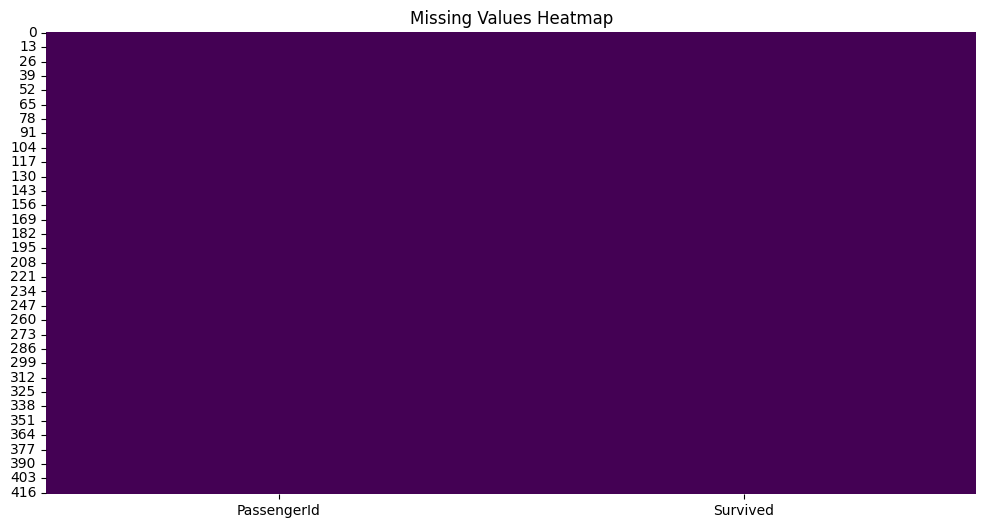

In [ ]:

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

In [ ]:


from sklearn.impute import SimpleImputer

num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns

num_imputer = SimpleImputer(strategy='median')
df[num_cols] = num_imputer.fit_transform(df[num_cols])

if len(cat_cols) > 0:
    cat_imputer = SimpleImputer(strategy='most_frequent')
    df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

print("Missing Values After Handling:")
print(df.isnull().sum())

Missing Values After Handling:
PassengerId    0
Survived       0
dtype: int64


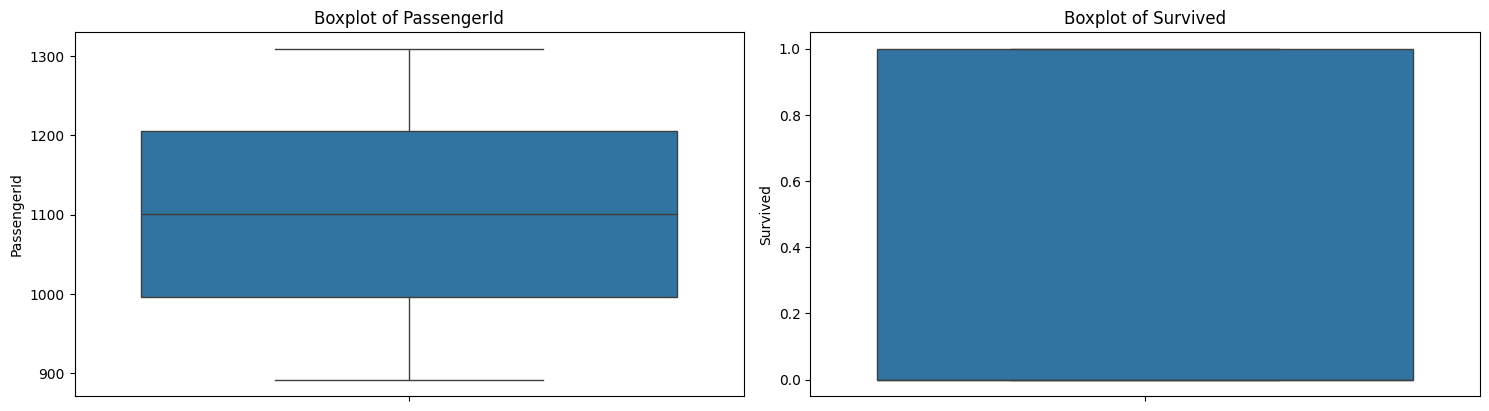

In [ ]:

numerical_features = num_cols

plt.figure(figsize=(15,8))

for i, col in enumerate(numerical_features[:4]):
    plt.subplot(2,2,i+1)
    sns.boxplot(y=df[col])
    plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

for col in numerical_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR


    df[col] = np.where(df[col] > upper, upper, df[col])
    df[col] = np.where(df[col] < lower, lower, df[col])

print("Outliers handled successfully.")

Outliers handled successfully.


In [ ]:

from sklearn.preprocessing import LabelEncoder

label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

print("\nDataset After Encoding:")
print(df.head())


Dataset After Encoding:
   PassengerId  Survived
0        892.0       0.0
1        893.0       1.0
2        894.0       0.0
3        895.0       0.0
4        896.0       1.0


In [ ]:
from sklearn.preprocessing import StandardScaler

print("Before Scaling:")
print(df.head())

scaler = StandardScaler()

scaled_df = pd.DataFrame(
    scaler.fit_transform(df),
    columns=df.columns
)

print("\nAfter Scaling:")
print(scaled_df.head())

Before Scaling:
   PassengerId  Survived
0        892.0       0.0
1        893.0       1.0
2        894.0       0.0
3        895.0       0.0
4        896.0       1.0

After Scaling:
   PassengerId  Survived
0    -1.727912 -0.755929
1    -1.719625  1.322876
2    -1.711337 -0.755929
3    -1.703050 -0.755929
4    -1.694763  1.322876


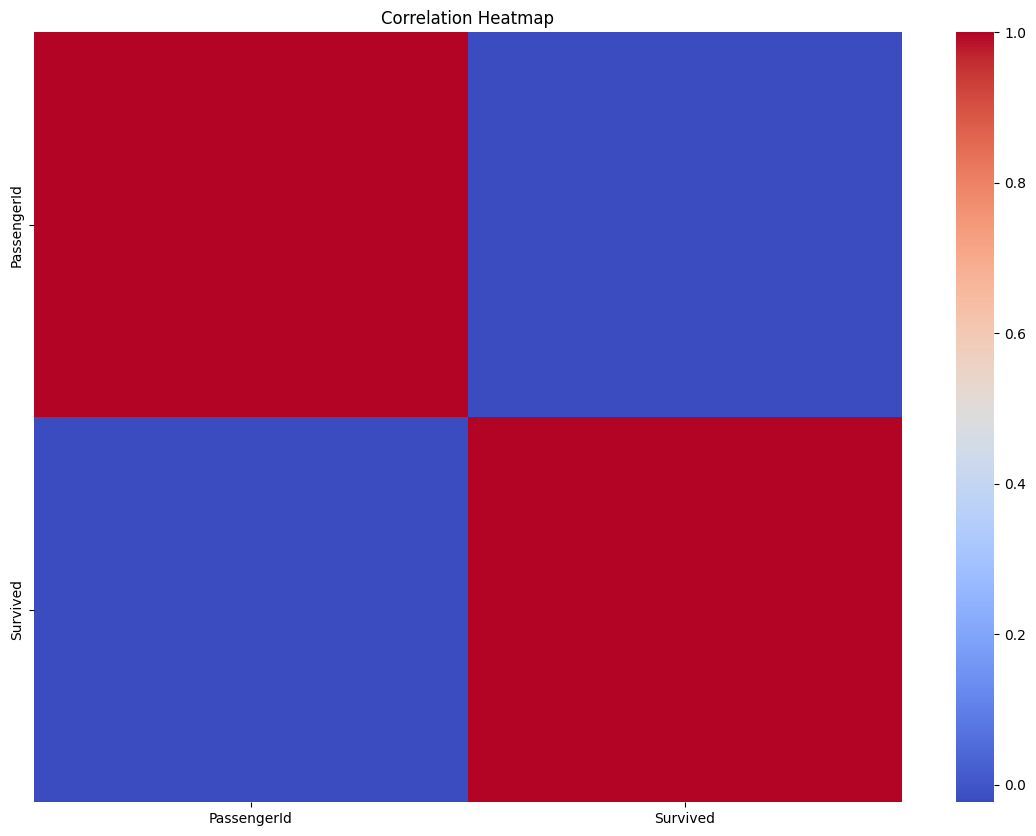

In [ ]:

plt.figure(figsize=(14,10))
sns.heatmap(scaled_df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [ ]:

print("Final Preprocessed Dataset Shape:")
print(scaled_df.shape)

print("\nFinal Dataset Summary:")
print(scaled_df.describe())

Final Preprocessed Dataset Shape:
(418, 2)

Final Dataset Summary:
       PassengerId      Survived
count   418.000000  4.180000e+02
mean      0.000000 -3.824692e-17
std       1.001198  1.001198e+00
min      -1.727912 -7.559289e-01
25%      -0.863956 -7.559289e-01
50%       0.000000 -7.559289e-01
75%       0.863956  1.322876e+00
max       1.727912  1.322876e+00
